# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\roozb\AppData\Local\Temp\ipykernel_42408\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

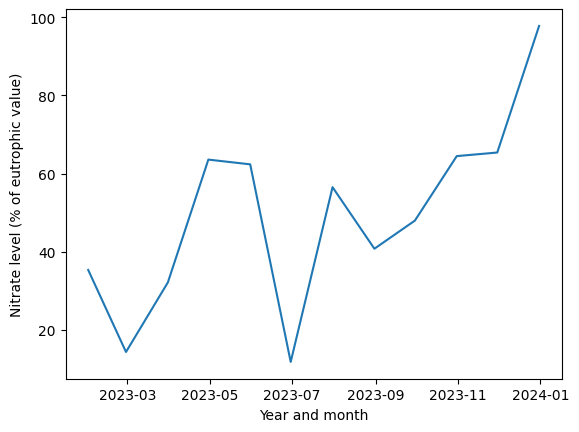

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\roozb\AppData\Local\Temp\ipykernel_42408\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

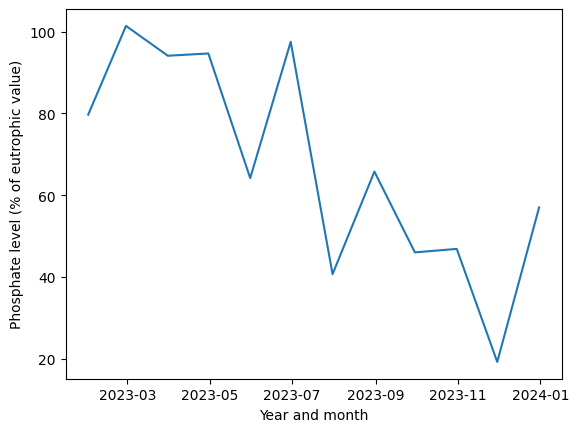

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

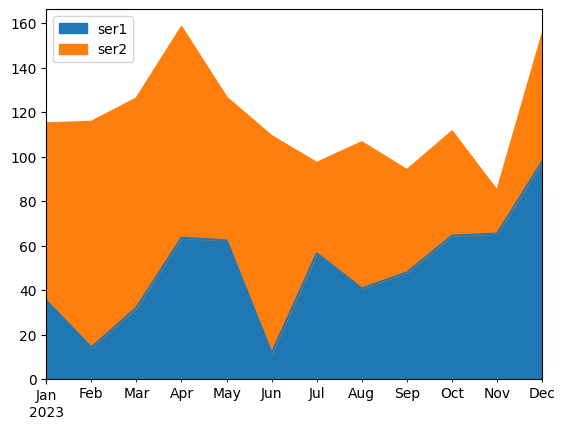

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

The area plot makes it easy to see the combined total level of nitrate and phosphate over time. It also shows how the total changes from month to month, so it can be useful if the main goal is to understand the overall nutrient level in the water sample.

However, the area plot is not as good for comparing the two individual chemicals. Because the second series is stacked on top of the first, it can be harder to see the exact phosphate pattern by itself. The area plot can make the relationship between nitrate and phosphate look less clear than two separate line graphs.

The two separate line graphs make it easier to see the trend of each chemical individually. In this example, nitrate generally increases over time, while phosphate generally decreases and then changes again near the end. Separate line plots make those patterns easier to read.

To improve the presentation, I would give the variables clearer names instead of `ser1` and `ser2`, such as `Nitrate` and `Phosphate`. I would also use the same y-axis scale for both line plots so the viewer can compare them fairly. For the area plot, I would reduce the transparency and use clear labels or a legend. I would also add a title and more descriptive axis labels.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## **Week 6 Analysis: Bivariate Analysis**

For Week 6, I used the cleaned versions of the project datasets from the previous cleaning step. The goal of this section is to explore relationships between pairs of variables using correlation analysis, scatterplots, pairplots, and time-based visualizations when date or time variables are available.

This analysis focuses on understanding whether variables move together, whether any variables may be redundant because they are highly correlated, whether there are visible outliers in pairwise relationships, and whether there are possible confounding variables that could explain some of the relationships.

### **Dataset 1: E-commerce User Behavior**

This dataset contains customer demographic information, order and purchase details, and online engagement variables. In this section, I use the cleaned EDA version of the dataset, `df_behavior_eda`, to explore relationships between important numeric, categorical, engagement, and time-based variables.

For this bivariate analysis, I focus on relationships such as sales and profit, sales and shipping cost, browsing time and add-to-cart behavior, and possible changes in sales or profit over time.

#### **Dataset 1 Column Descriptions**

- `Customer ID`: Unique identifier for each customer.

- `Order ID`: Unique identifier for each order.

- `Order Date`: Date when the order was placed.

- `Age`: Customer age.

- `Segment`: Customer segment, such as Consumer, Corporate, or Home Office.

- `Country`: Customer country.

- `Region`: Customer region.

- `Gender`: Customer gender.

- `Education`: Customer education level.

- `Marital Status`: Customer marital status.

- `Months`: Month related to the order or customer activity.

- `Sales`: Sales amount for the order or product interaction.

- `Quantity`: Number of items purchased.

- `Discount`: Discount rate applied to the order.

- `Profit`: Profit amount from the order or product.

- `Shipping Cost`: Cost of shipping for the order.

- `Ship Mode`: Shipping method used for the order.

- `Product Category`: Category of the purchased or viewed product.

- `Order Priority`: Priority level of the order.

- `Browsing Time`: Time the customer spent browsing.

- `Like`: Binary engagement variable showing whether the customer liked the item; 1 means yes, 0 means no.

- `Share`: Binary engagement variable showing whether the customer shared the item; 1 means yes, 0 means no.

- `Add to Cart`: Binary engagement variable showing whether the customer added the item to cart; 1 means yes, 0 means no.

#### **1.1 load and check**

In [5]:
# Load the cleaned dataset from the previous cleaning step
df_behavior = pd.read_pickle("data/df_behavior_eda.pkl")

# Quick check
df_behavior.shape

(51207, 27)

In [6]:
df_behavior.head(5)

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,...,140.0,2.0,0.05,46.0,4.6,Medium,14.7,1,1,1
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,...,211.0,3.0,0.03,112.0,11.2,Medium,15.0,0,0,1
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,...,117.0,5.0,0.01,31.2,3.1,Critical,19.9,1,1,1
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,...,118.0,2.0,0.05,26.2,2.6,High,15.8,1,1,1
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,...,250.0,1.0,0.04,160.0,16.0,Critical,18.1,1,1,1


In [7]:
df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51207 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          51207 non-null  object        
 1   Customer Name        51207 non-null  object        
 2   Segment              51207 non-null  object        
 3   City                 51207 non-null  object        
 4   State                51207 non-null  object        
 5   Country              51207 non-null  object        
 6   Region               51207 non-null  object        
 7   Gender               51207 non-null  object        
 8   Age                  51207 non-null  int64         
 9   Education            51207 non-null  object        
 10  Marital Status       51207 non-null  object        
 11  Order ID             51207 non-null  object        
 12  Order Date           51207 non-null  datetime64[ns]
 13  Months               51207 non-null 

#### **1.2 Selecting Variables for Bivariate Analysis**
For this section, I selected the variables that are most useful for bivariate analysis. Numeric variables will be used for correlation analysis, scatterplots, and pairplots. Categorical variables will be used for grouped comparisons, and `Order Date` will be used for time-based analysis.

In [8]:
# Select variables for bivariate analysis
numeric_cols_behavior = ["Age","Sales","Quantity","Discount","Profit","Shipping Cost","Browsing Time (min)","Like","Share","Add to Cart"]

categorical_cols_behavior = ["Segment","Region","Gender","Education","Marital Status","Ship Mode","Product Category","Order Priority"]

time_col_behavior = "Order Date"

print("Numeric columns:")
print(numeric_cols_behavior)

print("\nCategorical columns:")
print(categorical_cols_behavior)

print("\nTime column:")
print(time_col_behavior)

Numeric columns:
['Age', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Browsing Time (min)', 'Like', 'Share', 'Add to Cart']

Categorical columns:
['Segment', 'Region', 'Gender', 'Education', 'Marital Status', 'Ship Mode', 'Product Category', 'Order Priority']

Time column:
Order Date


The selected numeric columns will be used for correlation analysis, scatterplots, and pairplots. The categorical columns will be used when comparing numeric variables across groups. The `Order Date` column will be used for time-based analysis, such as checking whether sales or profit change over time.

#### **1.3 Correlation Analysis**

In this section, I calculate the correlations between the selected numeric variables. This helps identify which variables move together and whether any variables may be strongly related or possibly redundant.  

I also include the binary engagement variables, such as Like, Share, and Add to Cart, but I will interpret them carefully because they only have values of 0 and 1.

In [9]:
# Correlation matrix for selected numeric variables

corr_behavior = df_behavior[numeric_cols_behavior].corr()

corr_behavior

,Age,Sales,Quantity,Discount,Profit,Shipping Cost,Browsing Time (min),Like,Share,Add to Cart
Age,1.000000,0.005089,0.000734,-0.003664,0.004288,0.004332,0.000281,0.000563,-0.007203,-0.005975
Sales,0.005089,1.000000,-0.000574,-0.007112,0.921507,0.921257,0.009482,-0.000997,-0.002601,0.008619
Quantity,0.000734,-0.000574,1.000000,0.007084,-0.176358,-0.176693,0.004708,0.002237,0.002438,0.001115
Discount,-0.003664,-0.007112,0.007084,1.000000,-0.118795,-0.119126,-0.003805,0.003690,-0.000807,0.002556
Profit,0.004288,0.921507,-0.176358,-0.118795,1.000000,0.999982,0.010728,-0.001697,-0.002187,0.010408
Shipping Cost,0.004332,0.921257,-0.176693,-0.119126,0.999982,1.000000,0.010741,-0.001689,-0.002164,0.010397
Browsing Time (min),0.000281,0.009482,0.004708,-0.003805,0.010728,0.010741,1.000000,0.131955,0.146960,0.107153
Like,0.000563,-0.000997,0.002237,0.003690,-0.001697,-0.001689,0.131955,1.000000,0.467778,0.335920
Share,-0.007203,-0.002601,0.002438,-0.000807,-0.002187,-0.002164,0.146960,0.467778,1.000000,0.377407
Add to Cart,-0.005975,0.008619,0.001115,0.002556,0.010408,0.010397,0.107153,0.335920,0.377407,1.000000


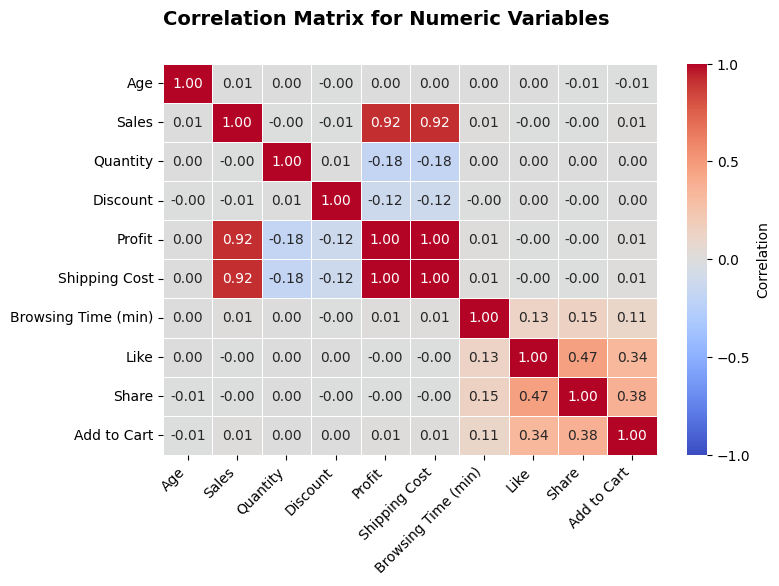

In [10]:
# Heatmap of numeric correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_behavior, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1,vmax=1,center=0, cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Matrix for Numeric Variables", loc="left", fontsize=14, fontweight="bold", pad=14, y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The correlation heatmap shows that most numeric variables have weak relationships with each other, but a few important patterns appear.

- Sales has a strong positive correlation with both Profit and Shipping Cost, around 0.92. This means higher sales values are generally associated with higher profit and higher shipping cost. Profit and Shipping Cost also have an almost perfect positive correlation, which suggests that these two variables may be highly related or possibly redundant in this dataset. This relationship should be interpreted carefully because one variable may be partly connected to how the other one was created, or both may be influenced by order value.

- Quantity and Discount have weak negative correlations with Profit and Shipping Cost. However, these relationships are small, so they do not show a strong inverse relationship.

- The target-like variable `Add to Cart` does not show strong correlation with most financial numeric variables such as Sales, Profit, Shipping Cost, Quantity, or Discount. Since `Add to Cart` is a binary variable, this correlation should be interpreted carefully. A low Pearson correlation does not necessarily mean there is no relationship at all; it only means there is no strong simple linear relationship in this correlation matrix.

- However, `Add to Cart` has moderate positive correlations with the engagement variables `Like` and `Share`. This suggests that customers who like or share an item are somewhat more likely to add it to the cart. Browsing Time also has a weak positive relationship with Like, Share, and Add to Cart, but the relationship is not strong by itself.

Overall, the strongest numeric relationships are between Sales, Profit, and Shipping Cost. For customer engagement and purchase intent, the most useful relationships appear to be between Like, Share, and Add to Cart rather than between Add to Cart and financial variables.

#### **1.4 Scatterplots for Important Numeric Relationships**

Based on the correlation matrix, I selected the strongest numeric relationships for scatterplot analysis. Scatterplots help show whether these relationships look linear, whether there are visible outliers, and whether some highly correlated variables may be redundant.

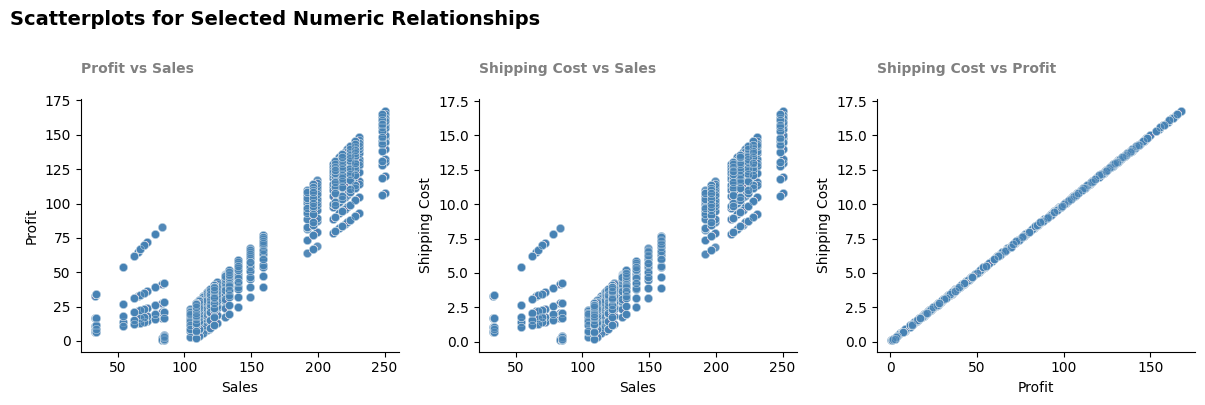

In [11]:
# Scatterplots for important numeric relationships
scatter_pairs_behavior = [("Sales", "Profit"),("Sales", "Shipping Cost"),("Profit", "Shipping Cost")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_behavior):
    sns.scatterplot(data=df_behavior,x=x_col,y=y_col,alpha=0.2,ax=ax[i], color = "steelblue")
    
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

The scatterplots confirm the strongest relationships from the correlation matrix.

Sales and Profit show a strong positive relationship. Higher Sales values are generally associated with higher Profit values, but the points form several visible groups instead of one smooth cloud. This suggests that the relationship may also be influenced by other variables, such as Product Category, Discount, Quantity, or order structure.

Sales and Shipping Cost show a very similar pattern. As Sales increases, Shipping Cost also tends to increase. This relationship is strong, but it also appears grouped rather than completely continuous.

Profit and Shipping Cost show an almost perfectly linear relationship. This confirms the very high correlation from the heatmap. Because the points fall almost exactly on a straight line, these two variables may be redundant or may be calculated from the same underlying structure.

Overall, these scatterplots suggest that Sales, Profit, and Shipping Cost are highly related. For later modeling or deeper analysis, Profit and Shipping Cost should be handled carefully because they may provide overlapping information.

#### **1.5 Add to Cart and Engagement Relationships**

Since `Add to Cart` is a binary target-like variable, scatterplots are not the best way to analyze its relationship with other variables. Instead, I compare add-to-cart behavior using engagement variables. This helps show whether users who like or share an item are also more likely to add it to the cart.

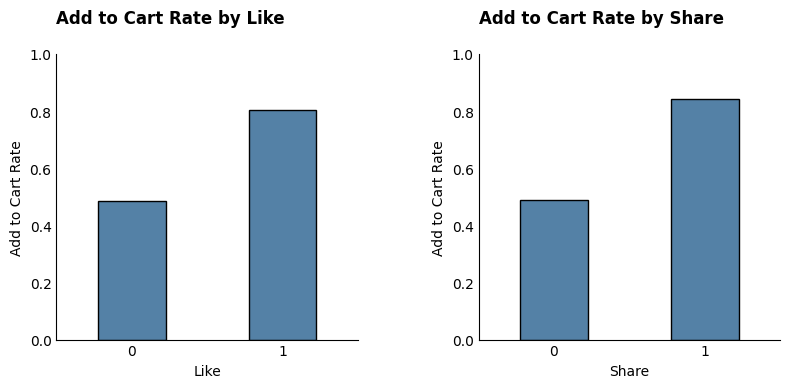

In [12]:
# Add to Cart rate by Like and Share

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.barplot(data=df_behavior,x="Like",y="Add to Cart", estimator="mean", errorbar=None, color="steelblue",width=0.45,ax=ax[0],edgecolor="black")
ax[0].set_title("Add to Cart Rate by Like", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax[0].set_xlabel("Like")
ax[0].set_ylabel("Add to Cart Rate")
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis = "x", length=0)
ax[0].tick_params(axis="y", length=0)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.barplot(data=df_behavior,x="Share", y="Add to Cart", estimator="mean",errorbar=None,color="steelblue",width=0.45,ax=ax[1],edgecolor="black")
ax[1].set_title("Add to Cart Rate by Share", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax[1].set_xlabel("Share")
ax[1].set_ylabel("Add to Cart Rate")
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis = "x", length=0)
ax[1].tick_params(axis="y", length=0)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

The bar plots show that users who liked or shared an item have a higher Add to Cart rate than users who did not.

For `Like`, the Add to Cart rate is clearly higher when `Like = 1` compared with `Like = 0`. A similar pattern appears for `Share`, where users who shared an item also have a higher Add to Cart rate.

This supports the correlation result from the heatmap. `Like` and `Share` have moderate positive relationships with `Add to Cart`, suggesting that engagement actions are related to purchase intent.  
However, this does not prove that liking or sharing causes users to add items to the cart; it only shows that these behaviors are associated in this dataset.

#### **1.6 Pairplot for Selected Numeric Variables**

In this section, I use a pairplot to compare several important numeric variables at the same time. The goal is to quickly review pairwise relationships, visible clusters, and distribution patterns among the main order-value variables.

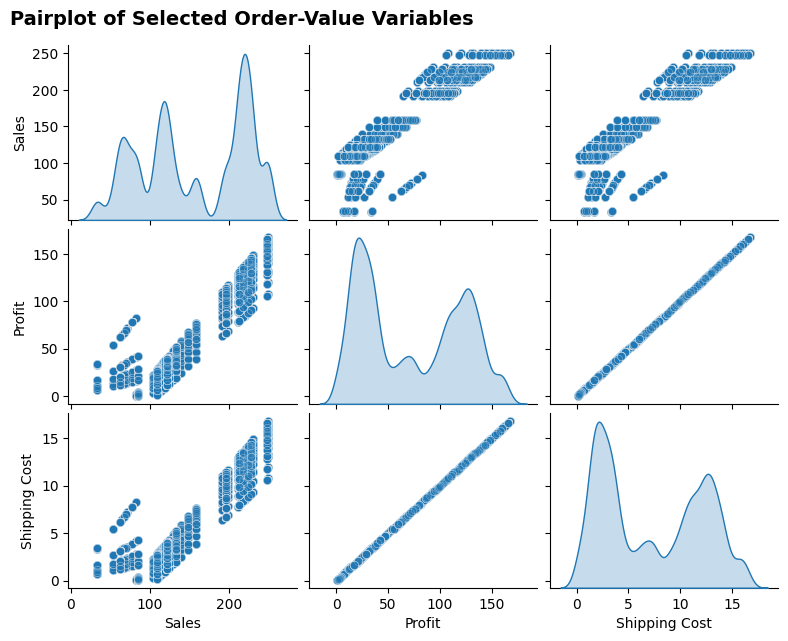

In [13]:
# Pairplot for selected order-value variables
pairplot_cols_behavior = ["Sales","Profit","Shipping Cost"]
g = sns.pairplot(data=df_behavior[pairplot_cols_behavior],diag_kind="kde",plot_kws={"alpha": 0.3})

g.fig.set_size_inches(8, 6)
g.fig.suptitle("Pairplot of Selected Order-Value Variables",fontsize=14, fontweight="bold", y=1.04, x=0.6, ha="right")
plt.show()

The pairplot focuses on the main order-value variables: Sales, Profit, and Shipping Cost. It confirms the strong relationships seen in the correlation heatmap and scatterplots.

Sales is positively related to both Profit and Shipping Cost, but the pattern is not completely smooth. The points form visible groups, which suggests that the relationship may also be influenced by other variables such as Product Category, Discount, Quantity, or order structure.

Profit and Shipping Cost show an almost perfectly linear relationship. This supports the very high correlation seen in the heatmap and suggests that these two variables may provide overlapping or redundant information.

Overall, the pairplot confirms that Sales, Profit, and Shipping Cost are strongly related, while also showing that the relationships have grouped patterns rather than one simple continuous cloud.

#### **1.7 Time-Based Analysis**

In this section, I use the `Order Date` column to check whether important numeric variables change over time. Line plots can help show trends, seasonality, or possible drift in the data.

In [14]:
# Monthly trend for Sales and Profit
monthly_behavior = (df_behavior.set_index("Order Date").resample("ME").agg({ "Sales": "mean", "Profit": "mean","Shipping Cost": "mean","Add to Cart": "mean"}).reset_index())
monthly_behavior.head()

,Order Date,Sales,Profit,Shipping Cost,Add to Cart
0,2022-01-31,154.279762,70.615013,7.062632,0.659392
1,2022-02-28,157.758782,74.100546,7.410226,0.686963
2,2022-03-31,156.849687,72.532359,7.253514,0.671538
3,2022-04-30,156.189655,73.028261,7.304123,0.661919
4,2022-05-31,158.125532,74.293901,7.429574,0.674468


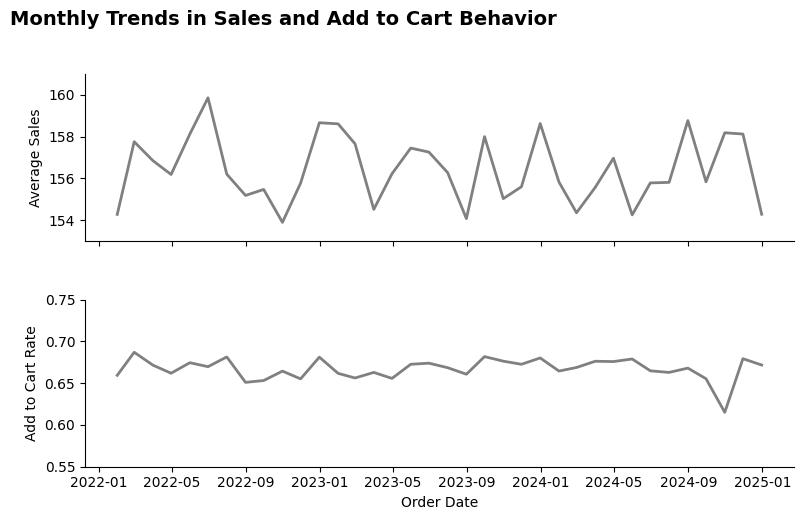

In [15]:
# Monthly trend for Sales and Add to Cart rate

monthly_behavior = (df_behavior.set_index("Order Date").resample("ME").agg({"Sales": "mean","Add to Cart": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_behavior,x="Order Date",y="Sales",ax=ax[0],linewidth=2,markersize=5, color = "gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Average Sales")
ax[0].set_ylim(153, 161)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.lineplot(data=monthly_behavior,x="Order Date",y="Add to Cart",linewidth=2, ax=ax[1],markersize=5, color ="gray")
ax[1].set_xlabel("Order Date")
ax[1].set_ylabel("Add to Cart Rate")
ax[1].set_ylim(0.55, 0.75)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

fig.suptitle("Monthly Trends in Sales and Add to Cart Behavior", fontsize=14, fontweight="bold", y=1.03, x=0, ha="left")

plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

The time-based line plots show monthly average Sales and monthly Add to Cart rate over time.   

The y-axes are focused on the observed value ranges to make the monthly changes easier to see.

Monthly average Sales changes from month to month, but it stays within a fairly narrow range, mostly around 154 to 160. There is no clear long-term upward or downward trend, so Sales appears relatively stable over the observed period.

The monthly Add to Cart rate is also fairly stable, mostly staying around 0.65 to 0.68. There is one visible dip near late 2024, but it does not appear to create a long-term downward trend.

Overall, the time-based analysis does not show strong evidence of drift in Sales or Add to Cart behavior. This suggests that time does not strongly change the main patterns in this dataset.

#### **1.8 Possible Confounding Variables**

In this section, I check whether another variable may help explain the relationship between Sales and Profit. From the previous plots, Sales and Profit had a strong relationship, but the points were not in one smooth pattern. They looked grouped, so I used Product Category to see if it explains part of this pattern.

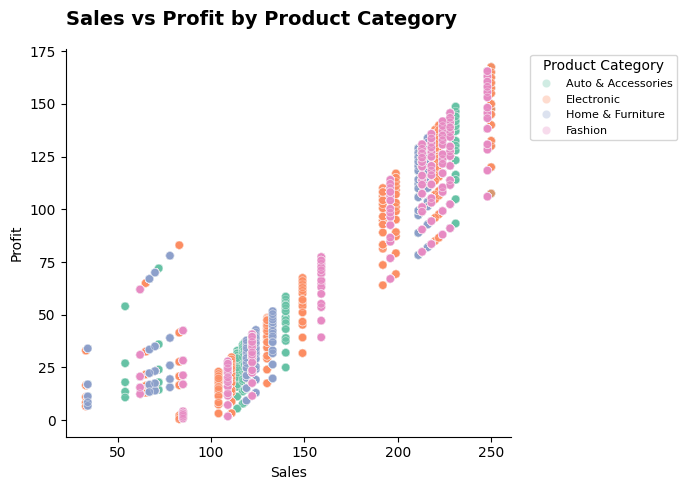

In [16]:
# Sales vs Profit colored by Product Category

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=df_behavior,x="Sales",y="Profit",hue="Product Category",alpha=0.3, palette="Set2")

plt.title("Sales vs Profit by Product Category", loc="left", fontsize=14, fontweight="bold", pad=12, y=1.02, x=0, ha="left")
plt.xlabel("Sales")
plt.ylabel("Profit")
ax.legend(title="Product Category", bbox_to_anchor=(1.03, 1), loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The scatterplot shows a strong positive relationship between Sales and Profit. As Sales increases, Profit usually increases too.

After coloring the points by Product Category, we can see that Product Category explains part of the grouped pattern. Some higher Sales and Profit areas include more Fashion records. However, the categories still overlap a lot, so Product Category does not fully explain the relationship by itself.

This means Product Category may be one factor behind the Sales-Profit relationship, but it is probably not the only factor. Other variables such as Quantity, Discount, Shipping Cost, or order structure may also affect Profit.

For Add to Cart behavior, Like and Share were related to higher Add to Cart rates. However, this does not mean Like or Share directly caused Add to Cart. These actions may all be connected to the customer’s interest in the product.

#### **1.9 Final Conclusion for Dataset 1**

The bivariate analysis shows that Dataset 1 is useful for studying relationships between order values, customer engagement, and add-to-cart behavior.

The strongest relationships are between Sales, Profit, and Shipping Cost.  

Sales has a strong positive relationship with both Profit and Shipping Cost.  

Profit and Shipping Cost are almost perfectly related, which suggests that these two variables may contain very similar information. Because of this, they should be used carefully in later analysis or modeling.

The scatterplots and pairplot confirmed these strong relationships. Sales and Profit increase together, but the points form visible groups instead of one smooth pattern. This suggests that other variables, such as Product Category, Quantity, Discount, or order structure, may also affect the relationship.

For the target-like variable `Add to Cart`, the correlation with financial variables such as Sales, Profit, and Shipping Cost is very weak. This suggests that order value alone does not explain add-to-cart behavior well.  
However, `Add to Cart` has a stronger relationship with engagement variables such as `Like` and `Share`. Users who liked or shared an item had a higher Add to Cart rate.

The time-based analysis did not show a strong upward or downward trend. Monthly average Sales stayed within a narrow range, and monthly Add to Cart rate was also fairly stable. There was no strong evidence of drift over time.

The possible confounding variable analysis showed that Product Category may explain part of the grouped pattern between Sales and Profit, but it does not fully explain the relationship. The categories still overlap, so other variables may also be involved.

Overall, the dataset looks usable for bivariate analysis. The main business insight is that Sales, Profit, and Shipping Cost are strongly connected, while Add to Cart behavior seems more related to customer engagement actions than to financial order-value variables.

### **Dataset 2: Sales and Customer Insights**

This dataset contains customer purchase behavior, customer value, churn probability, product category, region, retention strategy, and product-related timing variables. In this section, I use the cleaned EDA version of the dataset, `df_sales_eda`, to explore relationships between important numeric, categorical, churn-related, value-related, and time-based variables.

For this bivariate analysis, I focus on relationships such as churn probability and customer value, purchase frequency and average order value, lifetime value and region, churn probability and retention strategy, and possible changes in customer metrics over product launch or peak sales dates.

#### **Dataset 2 Column Descriptions**

- `Customer_ID`: Unique identifier for each customer.

- `Product_ID`: Unique identifier for each product.

- `Transaction_ID`: Unique identifier for each transaction.

- `Purchase_Frequency`: Number of purchases made by the customer.

- `Average_Order_Value`: Average amount spent per order.

- `Most_Frequent_Category`: Product category the customer buys most often.

- `Time_Between_Purchases`: Average time between purchases, likely in days.

- `Region`: Customer’s geographic region.

- `Churn_Probability`: Estimated probability that the customer may not return, from 0 to 1.

- `Lifetime_Value`: Estimated total value or revenue from the customer.

- `Launch_Date`: Launch date of the product connected to the customer record.

- `Peak_Sales_Date`: Date when the product reached its highest sales activity.

- `Season`: Season related to the product’s peak sales activity.

- `Preferred_Purchase_Times`: Time of day when the customer usually prefers to purchase.

- `Retention_Strategy`: Strategy used to keep or retain the customer.

#### **2.1 load and check**

In [17]:
# Load the cleaned dataset from the previous cleaning step
df_sales = pd.read_pickle("data/df_sales_eda.pkl")

# Quick check
df_sales.shape

(10000, 15)

In [18]:
df_sales.head(5)

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [19]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_ID               10000 non-null  object        
 1   Product_ID                10000 non-null  object        
 2   Transaction_ID            10000 non-null  object        
 3   Purchase_Frequency        10000 non-null  int64         
 4   Average_Order_Value       10000 non-null  float64       
 5   Most_Frequent_Category    10000 non-null  object        
 6   Time_Between_Purchases    10000 non-null  int64         
 7   Region                    10000 non-null  object        
 8   Churn_Probability         10000 non-null  float64       
 9   Lifetime_Value            10000 non-null  float64       
 10  Launch_Date               10000 non-null  datetime64[ns]
 11  Peak_Sales_Date           10000 non-null  datetime64[ns]
 12  Season             

#### **2.2 Selecting Variables for Bivariate Analysis**

For this bivariate analysis, I selected numeric variables for correlation analysis, scatterplots, and pairplots. I also selected categorical variables that may be useful for grouped comparisons or possible confounding-variable checks.

In [20]:
numeric_cols_sales_bivariate = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]

categorical_cols_sales_bivariate = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

date_cols_sales_bivariate = ["Launch_Date","Peak_Sales_Date"]

identifier_cols_sales = ["Customer_ID","Product_ID","Transaction_ID"]

print("Numeric variables for correlation, scatterplots, and pairplots:")
print(numeric_cols_sales_bivariate)

print("\nCategorical variables for grouped comparisons and possible confounding checks:")
print(categorical_cols_sales_bivariate)

print("\nDate variables for time-based analysis:")
print(date_cols_sales_bivariate)

print("\nIdentifier columns not used as main analysis variables:")
print(identifier_cols_sales)

Numeric variables for correlation, scatterplots, and pairplots:
['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

Categorical variables for grouped comparisons and possible confounding checks:
['Most_Frequent_Category', 'Region', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy']

Date variables for time-based analysis:
['Launch_Date', 'Peak_Sales_Date']

Identifier columns not used as main analysis variables:
['Customer_ID', 'Product_ID', 'Transaction_ID']


The selected numeric variables are used for correlation analysis, scatterplots, and pairplots. These variables describe customer purchase behavior, customer value, churn risk, and purchase timing.

The selected categorical variables may be used for grouped comparisons and possible confounding-variable checks. For example, Region, Most_Frequent_Category, and Retention_Strategy may help explain differences in customer value or churn probability.

Customer_ID, Product_ID, and Transaction_ID are kept in the dataset for reference, but they are not used as main analysis variables because they are identifier columns.

#### **2.3 Correlation Analysis**

In this step, I calculated correlations between the selected numeric variables. The goal is to identify which variables have stronger or weaker linear relationships before choosing scatterplots.

In [21]:
# Correlation matrix for selected numeric variables
corr_sales = df_sales[numeric_cols_sales_bivariate].corr()
corr_sales

,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value
Purchase_Frequency,1.000000,-0.000072,-0.008885,0.018417,0.007010
Average_Order_Value,-0.000072,1.000000,0.004417,-0.000871,0.004184
Time_Between_Purchases,-0.008885,0.004417,1.000000,0.010410,0.010418
Churn_Probability,0.018417,-0.000871,0.010410,1.000000,-0.006847
Lifetime_Value,0.007010,0.004184,0.010418,-0.006847,1.000000


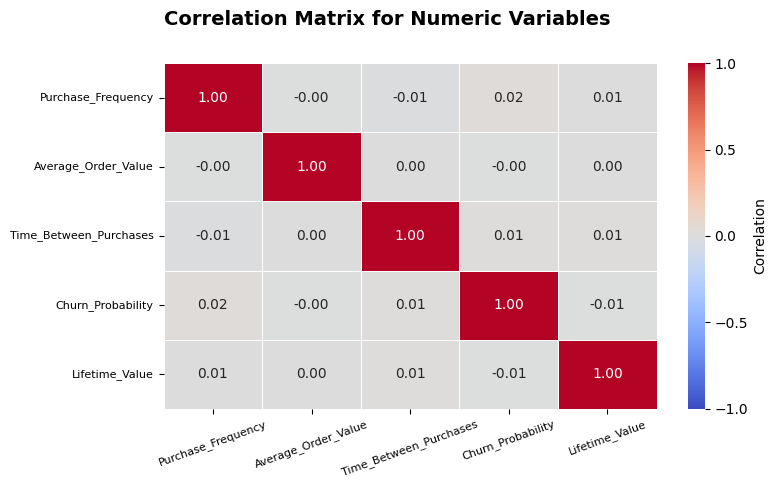

In [22]:
# Heatmap of correlations
plt.figure(figsize=(8, 5))
sns.heatmap(corr_sales, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.5, vmin=-1,vmax=1,center=0, cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
plt.xticks(rotation=20, fontsize=8)
plt.yticks(fontsize=8)
plt.title("Correlation Matrix for Numeric Variables", loc="left", fontsize=14, fontweight="bold", pad=15, y=1.05, x=0)
plt.tight_layout()
plt.show()

The correlation heatmap shows that there are no meaningful linear relationships between the selected numeric variables. All correlation values are very close to 0.

This means the numeric variables do not show clear linear relationships with each other. There are also no highly correlated or redundant numeric variables in this dataset.

Because the correlations are very weak, scatterplots will likely show scattered points without clear patterns. However, I will still create a few scatterplots for business-related variable pairs to visually confirm this result.

This result is consistent with the Week 4 observation that Dataset 2 appears very evenly distributed and may be synthetic or generated for analysis practice.

#### **2.4 Scatterplots for Selected Numeric Pairs**

Since the correlation heatmap did not show meaningful linear relationships, I selected a few business-related numeric pairs to visually check whether any clear pattern appears in scatterplots.

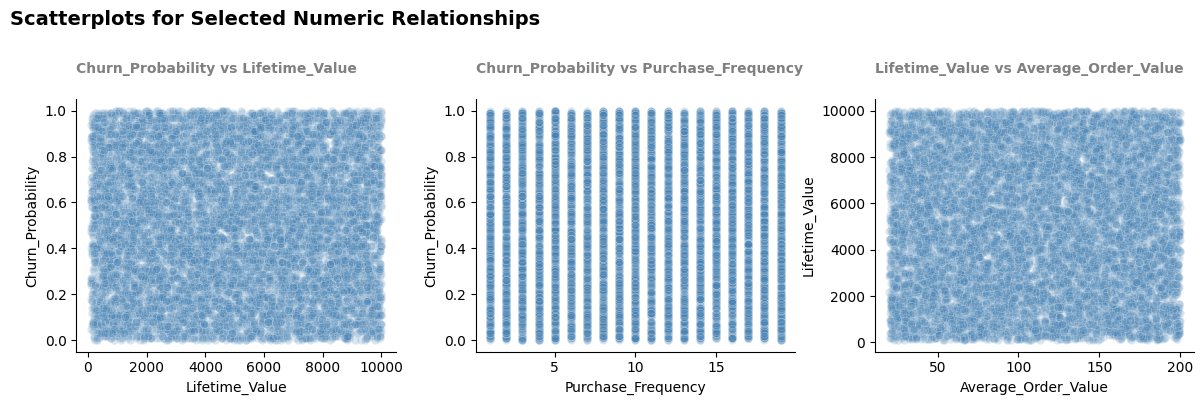

In [23]:
# Scatterplots for selected business-related numeric pairs
scatter_pairs_sales = [("Lifetime_Value", "Churn_Probability"),("Purchase_Frequency", "Churn_Probability"), ("Average_Order_Value", "Lifetime_Value")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_sales):
    sns.scatterplot(data=df_sales,x=x_col, y=y_col,alpha=0.2,ax=ax[i],color="steelblue")
    
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

The scatterplots confirm the weak correlation results from the heatmap. The points are widely spread across the plot areas, and none of the selected numeric pairs show a clear linear pattern.

For Lifetime_Value vs Churn_Probability, customers with low and high lifetime value appear across the full churn probability range. This suggests that higher customer value is not clearly associated with lower or higher churn probability in this dataset.

For Purchase_Frequency vs Churn_Probability, the vertical bands appear because Purchase_Frequency is a discrete numeric variable. Churn probability is still spread across the full 0 to 1 range for almost every purchase frequency level.

For Average_Order_Value vs Lifetime_Value, the points are spread across almost the full range of both variables, with no clear upward or downward trend.

Overall, these scatterplots support the correlation analysis. The selected numeric variables do not show meaningful linear relationships, which is consistent with the balanced and synthetic-looking structure observed earlier in Dataset 2.

#### **2.5 Pairplot for Selected Numeric Variables**

In this step, I created a pairplot for the selected numeric variables. The goal is to visually check the relationships between multiple numeric variables at the same time.

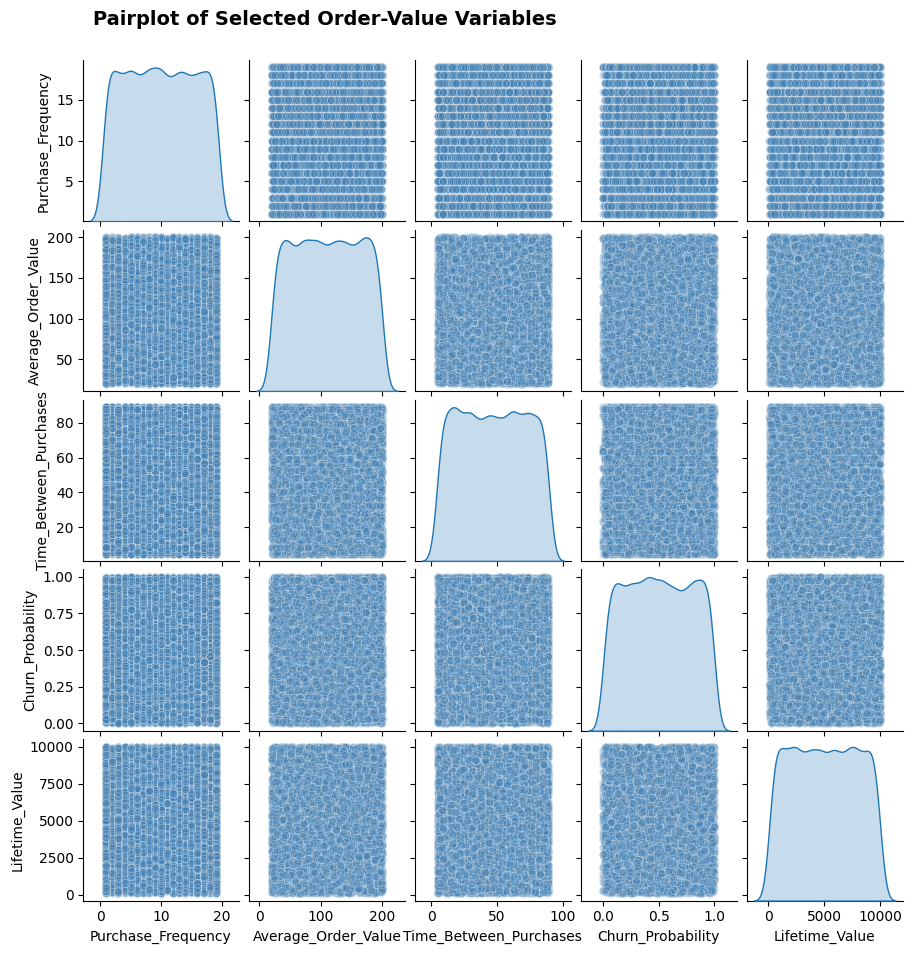

In [24]:
# Pairplot for selected numeric variables
g = sns.pairplot(df_sales[numeric_cols_sales_bivariate],diag_kind="kde",plot_kws={"alpha": 0.3, "color": "steelblue"})
g.fig.set_size_inches(9, 9)
g.fig.suptitle("Pairplot of Selected Order-Value Variables",fontsize=14, fontweight="bold", y=1.04, x=0.6, ha="right")
plt.show()

The pairplot confirms the previous results. The numeric variables are broadly spread and do not show clear relationships with each other.

Purchase_Frequency appears as bands because it is a discrete variable. Overall, the pairplot does not show meaningful bivariate patterns.

#### **2.6 Time-Based Analysis**

Dataset 2 includes product-related date columns. In this step, I use Peak_Sales_Date to check whether customer-related metrics show any visible pattern over product peak-sales time.

In [25]:
# Monthly trend for customer metrics based on product peak sales date
monthly_sales = (df_sales.set_index("Peak_Sales_Date").resample("ME").agg({"Churn_Probability": "mean","Lifetime_Value": "mean","Average_Order_Value": "mean","Purchase_Frequency": "mean"}).reset_index())
monthly_sales.head()

,Peak_Sales_Date,Churn_Probability,Lifetime_Value,Average_Order_Value,Purchase_Frequency
0,2023-01-31,0.492229,4998.496097,109.116029,9.886878
1,2023-02-28,0.506074,4786.037724,108.399744,9.668798
2,2023-03-31,0.501876,5011.729032,109.166822,10.041816
3,2023-04-30,0.523463,5075.221083,111.585491,10.086902
4,2023-05-31,0.509932,4895.581499,108.626144,9.461105


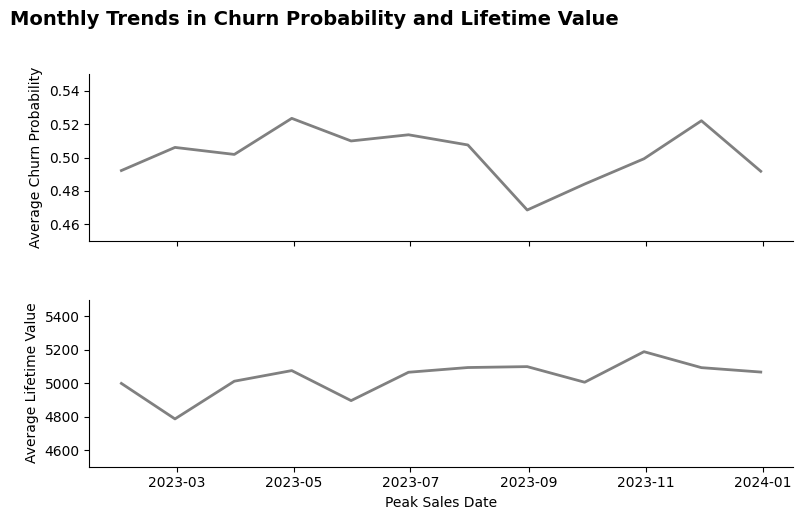

In [26]:
# Monthly trend for churn probability and lifetime value

monthly_sales = (df_sales.set_index("Peak_Sales_Date").resample("ME").agg({"Churn_Probability": "mean","Lifetime_Value": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_sales,x="Peak_Sales_Date",y="Churn_Probability",ax=ax[0],linewidth=2,markersize=5,color="gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Average Churn Probability")
ax[0].set_ylim(0.45, 0.55)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

sns.lineplot(data=monthly_sales,x="Peak_Sales_Date",y="Lifetime_Value",linewidth=2,ax=ax[1],markersize=5,color="gray")
ax[1].set_xlabel("Peak Sales Date")
ax[1].set_ylabel("Average Lifetime Value")
ax[1].set_ylim(4500, 5500)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

fig.suptitle("Monthly Trends in Churn Probability and Lifetime Value",fontsize=14,fontweight="bold",y=1.03, x=0, ha="left")

plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

The monthly line plots show that average Churn_Probability and average Lifetime_Value fluctuate slightly over product peak-sales months, but there is no clear long-term upward or downward trend.

Average Churn_Probability stays close to 0.50 across most months, with small month-to-month changes. Average Lifetime_Value also stays around the same general range, mostly near 5,000.

Overall, these time-based plots do not show strong evidence of drift over time. The customer-related metrics appear fairly stable across product peak-sales months.

#### **2.7 Possible Confounding Variables**

Because the numeric variables in Dataset 2 have very weak correlations, there is no clear numeric relationship that needs a detailed confounding-variable explanation. I considered Most_Frequent_Category, Region, and Retention_Strategy as possible third variables, but the earlier grouped plots showed heavy overlap across categories.

Therefore, there is no clear evidence that a categorical variable explains a hidden relationship between the selected numeric variables in this dataset.

#### **2.8 Final Conclusion for Dataset 2**

The Week 5 bivariate analysis shows that Dataset 2 does not provide meaningful business insight from the selected relationships.

- The correlation heatmap showed that all numeric correlations are very close to 0. This means the selected numeric variables do not have meaningful linear relationships with each other.

- The scatterplots confirmed the same result. The points were broadly scattered, and there were no clear upward, downward, clustered, or segmented patterns.

- The pairplot also did not reveal useful bivariate patterns. The variables were spread across their ranges, but no meaningful relationships appeared.

- The time-based analysis using Peak_Sales_Date showed only small month-to-month changes in average Churn_Probability and average Lifetime_Value. There was no clear trend, seasonal pattern, or meaningful drift over product peak-sales months.

- Possible confounding variables such as Most_Frequent_Category, Region, and Retention_Strategy did not explain any hidden relationship. The earlier grouped plots showed heavy overlap across categories.

Overall, Dataset 2 appears to be synthetic or artificially generated. The variables are too evenly distributed, the correlations are almost zero, the scatterplots do not show meaningful relationships, and the grouped comparisons do not separate the data well.

Because of this, Dataset 2 has very limited value for business analysis. It does not provide useful evidence about customer behavior, churn risk, customer value, or retention strategy. Any business conclusion from this dataset should be very cautious, because the data do not show realistic or meaningful relationships between the variables.

### **Dataset 3: E-commerce Customer Churn Analysis and Prediction**

- This dataset is customer-based. Each row represents one unique customer and includes information about customer behavior, satisfaction, complaints, order activity, and churn status.

- It contains variables such as tenure, preferred login device, city tier, warehouse-to-home distance, time spent on the app, order count, coupon usage, satisfaction score, complaint status, cashback amount, and churn.

- In this section, I use the EDA version of the dataset, `df_churn_eda`, to explore important numeric and categorical variables related to customer behavior, satisfaction, engagement, order activity, and churn risk. 


#### **Dataset 3 Column Descriptions**

- `CustomerID`: Unique ID for each customer.

- `Churn`: Target variable showing whether the customer churned; 1 means churned, 0 means not churned.

- `Tenure`: How long the customer has been with the company, likely in months.

- `PreferredLoginDevice`: The device the customer usually uses to log in, such as mobile phone or computer.

- `CityTier`: The tier/category of the customer’s city, usually from 1 to 3.

- `WarehouseToHome`: Distance between the warehouse and the customer’s home, likely in kilometers.

- `PreferredPaymentMode`: The customer’s preferred payment method.

- `Gender`: Customer gender.

- `HourSpendOnApp`: Number of hours the customer spends on the app.

- `NumberOfDeviceRegistered`: Number of devices registered by the customer.

- `PreferedOrderCat`: The customer’s preferred order/product category.

- `SatisfactionScore`: Customer satisfaction score, from 1 to 5.

- `MaritalStatus`: Customer marital status.

- `NumberOfAddress`: Number of addresses saved by the customer.

- `Complain`: Whether the customer complained; 1 means yes, 0 means no.

- `OrderAmountHikeFromlastYear`: Increase in order amount compared with last year, likely as a percentage.

- `CouponUsed`: Number of coupons used by the customer.

- `OrderCount`: Number of orders placed by the customer.

- `DaySinceLastOrder`: Number of days since the customer’s last order.

- `CashbackAmount`: Cashback amount received by the customer.

#### **3.1 load and check**

In [27]:
# Load the cleaned dataset from the previous cleaning step
df_churn = pd.read_pickle("data/df_churn_eda.pkl")

# Quick check
df_churn.shape

(5630, 20)

In [28]:
df_churn.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [29]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

#### **3.2 Selecting Variables for Bivariate Analysis**

For this bivariate analysis, I selected numeric variables for correlation analysis, scatterplots, and pairplots.

I also selected categorical variables that may be useful for grouped comparisons or possible confounding-variable checks.

Since this dataset is focused on customer churn, `Churn` will be treated as the main target-like variable for comparison.

In [30]:
numeric_cols_churn = ["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered","SatisfactionScore","NumberOfAddress","Complain","OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Churn"]
categorical_cols_churn = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]
identifier_cols_churn = ["CustomerID"]
target_col_churn = "Churn"

print("Numeric columns:")
print(numeric_cols_churn)

print("\nCategorical columns:")
print(categorical_cols_churn)

print("\nIdentifier columns:")
print(identifier_cols_churn)

print("\nTarget-like column:")
print(target_col_churn)

Numeric columns:
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Identifier columns:
['CustomerID']

Target-like column:
Churn


#### **3.3 Correlation Analysis**

In this step, I will calculate the correlation between selected numeric variables.

The goal is to see whether any numeric variables have strong positive or negative relationships.

Since `Churn` is a binary variable, its correlation with other numeric variables should be interpreted carefully.

In [31]:
# Correlation matrix for selected numeric variables

corr_churn = df_churn[numeric_cols_churn].corr()

corr_churn

,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
Tenure,1.000000,-0.018218,-0.021226,-0.023983,-0.013903,0.237666,-0.021268,0.005825,0.129035,0.186403,0.184552,0.476380,-0.349408
WarehouseToHome,-0.018218,1.000000,0.060990,0.019071,0.007722,-0.011020,0.028696,0.038795,-0.003935,0.002681,0.017829,-0.009200,0.076630
HourSpendOnApp,-0.021226,0.060990,1.000000,0.316800,0.031858,0.145126,0.006976,0.106843,0.191528,0.109575,0.075716,0.121490,0.018675
NumberOfDeviceRegistered,-0.023983,0.019071,0.316800,1.000000,-0.017228,0.084997,0.003407,0.069475,0.151685,0.103464,0.018208,0.137183,0.107939
SatisfactionScore,-0.013903,0.007722,0.031858,-0.017228,1.000000,0.053583,-0.031115,-0.027730,0.017936,0.019764,0.032082,0.003473,0.105481
NumberOfAddress,0.237666,-0.011020,0.145126,0.084997,0.053583,1.000000,-0.026399,0.015533,0.042120,-0.007609,-0.064847,0.186688,0.043931
Complain,-0.021268,0.028696,0.006976,0.003407,-0.031115,-0.026399,1.000000,-0.004529,-0.008174,-0.019307,-0.043546,0.000525,0.250188
OrderAmountHikeFromlastYear,0.005825,0.038795,0.106843,0.069475,-0.027730,0.015533,-0.004529,1.000000,0.033201,0.023101,0.006003,0.017869,-0.010058
CouponUsed,0.129035,-0.003935,0.191528,0.151685,0.017936,0.042120,-0.008174,0.033201,1.000000,0.745245,0.358930,0.286728,-0.008264
OrderCount,0.186403,0.002681,0.109575,0.103464,0.019764,-0.007609,-0.019307,0.023101,0.745245,1.000000,0.497928,0.360984,-0.028697


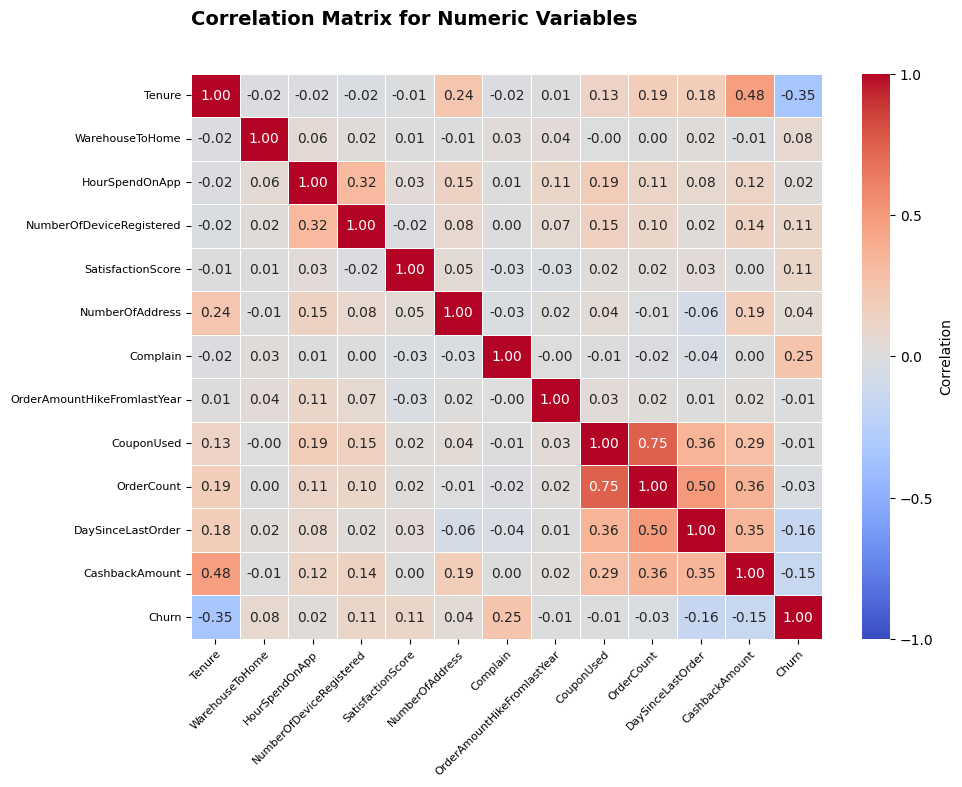

In [32]:
# Heatmap of correlations

plt.figure(figsize=(10, 8))

ax = sns.heatmap(corr_churn,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

The correlation heatmap shows that most numeric relationships in Dataset 3 are weak.

The strongest positive correlation is between `CouponUsed` and `OrderCount`, with a correlation of about 0.75. This makes sense because customers who place more orders may also use more coupons.

`OrderCount` and `DaySinceLastOrder` also have a moderate positive correlation of about 0.50.

`Tenure` and `CashbackAmount` have a moderate positive correlation of about 0.48. This may suggest that customers with longer tenure tend to receive or accumulate higher cashback amounts.

For the target-like variable `Churn`, the strongest relationship is with `Tenure`, with a negative correlation of about -0.35. This suggests that customers with longer tenure are less likely to churn.

`Complain` has a positive correlation with `Churn` of about 0.25, which suggests that customers who complained may be more likely to churn.

Other relationships with `Churn`, such as `DaySinceLastOrder`, `CashbackAmount`, and `WarehouseToHome`, are weaker.

Overall, the heatmap shows a few moderate relationships, but most correlations are not strong. Correlation does not prove causation, so these patterns should be explored with plots before making stronger conclusions.

#### **3.4 Scatterplots for Selected Numeric Relationships**

In this step, I will use scatterplots for selected numeric pairs from the correlation heatmap.

I will not plot every possible pair. I will focus on relationships that had stronger or more useful correlations.

The goal is to check whether these relationships look clear, linear, clustered, or weak in the actual plots.

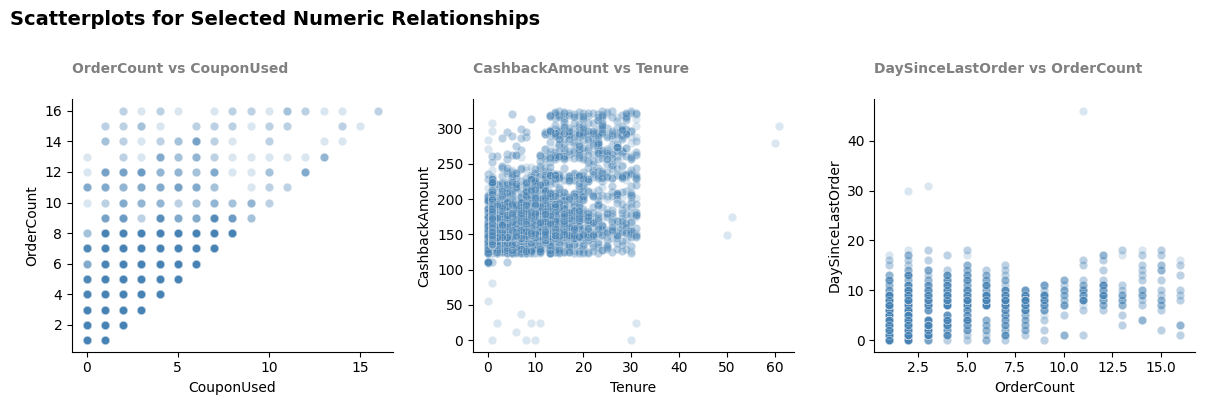

In [33]:
# Scatterplots for selected numeric relationships
scatter_pairs_churn = [("CouponUsed", "OrderCount"),("Tenure", "CashbackAmount"),("OrderCount", "DaySinceLastOrder")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_churn):
    sns.scatterplot(data=df_churn,x=x_col,y=y_col,alpha=0.2,ax=ax[i],color="steelblue")
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

The scatterplots confirm some of the patterns from the correlation heatmap.

`CouponUsed` and `OrderCount` show the clearest positive relationship. Customers with more orders tend to use more coupons. Since both variables are count-based, the points appear in a grid-like pattern rather than a smooth cloud.

`Tenure` and `CashbackAmount` also show a positive relationship, but the points are widely spread. Customers with longer tenure often have higher cashback amounts, but the relationship is not perfectly linear.

`OrderCount` and `DaySinceLastOrder` show some positive pattern, but it is weaker and less clear in the scatterplot. The points are spread out, and the relationship does not look strongly linear.

Overall, the scatterplots support the heatmap results. Some relationships are visible, but only `CouponUsed` and `OrderCount` show a clearly strong pattern.  

I did not include `Churn` in these scatterplots because it is a binary variable. Relationships with `Churn` are better explored using grouped plots, boxplots, violin plots, or churn-rate bar plots instead of regular scatterplots.

#### **3.5 Pairplot for Selected Numeric Variables**

In this step, I will create a pairplot for a small group of selected numeric variables.

I will not include all numeric columns because that would make the plot too crowded.

The goal is to compare several important numeric relationships at the same time and see whether the churn groups show different patterns.

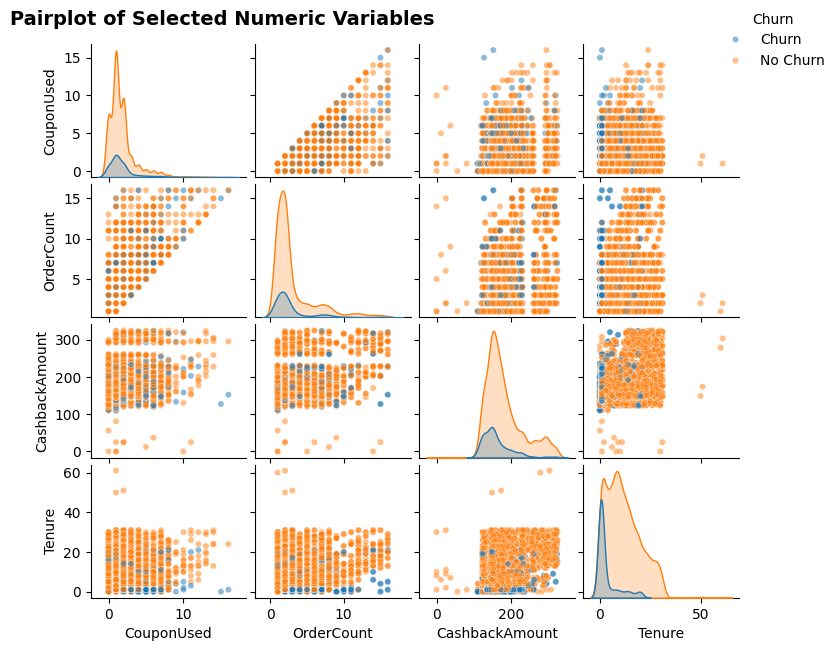

In [34]:
# Pairplot for selected numeric variables
pairplot_cols_churn = ["CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Tenure","Churn"]
churn_pairplot = df_churn[pairplot_cols_churn].copy()
churn_pairplot["Churn"] = churn_pairplot["Churn"].map({0: "No Churn",1: "Churn"})

g = sns.pairplot(data=churn_pairplot,vars=["CouponUsed", "OrderCount", "CashbackAmount", "Tenure"], hue="Churn",diag_kind="kde",plot_kws={"alpha": 0.5,"s": 20})

g.fig.set_size_inches(8,6)
g.fig.suptitle("Pairplot of Selected Numeric Variables",fontsize=14, fontweight="bold", y=1.04, x=0.5, ha="right")
g._legend.set_loc("upper right")
plt.show()


The pairplot gives a broader view of the selected numeric relationships.

The clearest relationship is between `CouponUsed` and `OrderCount`. Customers with more orders tend to use more coupons. Since both variables are count-based, the points appear in a grid-like pattern.

`Tenure` and `CashbackAmount` also show a positive relationship, but the points are widely spread, so the relationship is not perfectly linear.

The churn groups overlap heavily in most pairwise plots. The clearest churn-related pattern appears in `Tenure`, where churned customers are more concentrated at lower tenure values.

Overall, the pairplot supports the correlation and scatterplot results. It shows some useful relationships, but most variables do not clearly separate churned and non-churned customers by themselves.

#### **3.6 Time-Based Analysis**

Dataset 3 does not include a true date or time column.

Columns such as `DaySinceLastOrder` describe recency, but they are not actual calendar dates. Because of this, a line plot or area plot over time would not be meaningful for this dataset.

I will not force a time-based plot here because there is no clear time variable to show trend, seasonality, or drift.

#### **3.7 Churn Relationships and Possible Confounding Variables**

In this step, I will focus on relationships with `Churn`.

Since `Churn` is a binary variable, regular scatterplots are not the best option.

Instead, I will use churn-rate comparisons across selected categorical or binary variables.

The goal is to see whether churn rate changes across customer groups and whether any variable may help explain churn patterns.

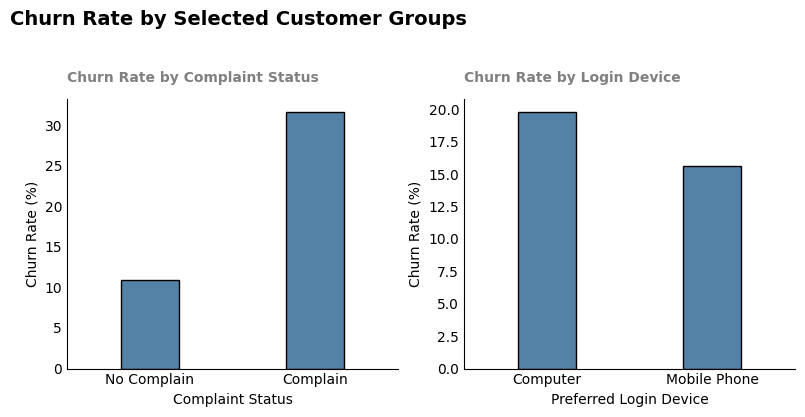

In [35]:
# Churn rate by Complain and Preferred Login Device

complain_churn_rate = df_churn.groupby("Complain")["Churn"].mean().reset_index()
complain_churn_rate["Churn_Rate"] = complain_churn_rate["Churn"] * 100
complain_churn_rate["Complain_Label"] = complain_churn_rate["Complain"].map({0: "No Complain", 1: "Complain"})

login_churn_rate = df_churn.groupby("PreferredLoginDevice")["Churn"].mean().reset_index()
login_churn_rate["Churn_Rate"] = login_churn_rate["Churn"] * 100

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.barplot(data=complain_churn_rate, x="Complain_Label", y="Churn_Rate", width=0.35, color="steelblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Churn Rate by Complaint Status", loc="left", fontsize=10, fontweight="bold", pad=12, color="gray")
axes[0].set_xlabel("Complaint Status")
axes[0].set_ylabel("Churn Rate (%)")

sns.barplot(data=login_churn_rate, x="PreferredLoginDevice", y="Churn_Rate", width=0.35, color="steelblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Churn Rate by Login Device", loc="left", fontsize=10, fontweight="bold", pad=12, color="gray")
axes[1].set_xlabel("Preferred Login Device")
axes[1].set_ylabel("Churn Rate (%)")

for ax in axes:
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Churn Rate by Selected Customer Groups", fontsize=14, fontweight="bold", y=1.03, x=0, ha="left")
plt.tight_layout()
fig.subplots_adjust(wspace=0.2)
plt.show()

The churn rate plots show that churn rate changes across selected customer groups.

Complaint status shows a clear difference. Customers who complained have a much higher churn rate than customers who did not complain.

Preferred login device also shows some difference. Customers who use `Computer` have a higher churn rate than customers who use `Mobile Phone`.

However, the difference for login device is smaller than the difference for complaint status.

Overall, complaint status appears to be more strongly related to churn than preferred login device. These results show association, not causation.

#### **3.8 Final Conclusion for Dataset 3**

The Week 5 bivariate analysis shows that Dataset 3 has some useful relationships for understanding customer churn, but most numeric relationships are not very strong.

The correlation heatmap showed that most numeric correlations are weak. The strongest relationship was between `CouponUsed` and `OrderCount`, with a correlation of about 0.75. This makes sense because customers with more orders may also use more coupons.

`OrderCount` and `DaySinceLastOrder` had a moderate positive relationship, and `Tenure` and `CashbackAmount` also showed a moderate positive relationship. These relationships were also visible in the scatterplots, but they were not perfectly linear.

For the target-like variable `Churn`, the strongest numeric relationship was with `Tenure`, with a negative correlation. This suggests that customers with longer tenure are less likely to churn. `Complain` also had a positive relationship with `Churn`, meaning customers who complained had a higher churn rate.

The scatterplots supported the heatmap results. `CouponUsed` and `OrderCount` showed the clearest pattern. Other relationships, such as `Tenure` with `CashbackAmount` and `OrderCount` with `DaySinceLastOrder`, showed some pattern but also had a lot of spread.

The pairplot gave a broader view of the selected numeric relationships. It showed that most churn and non-churn groups overlap heavily. The clearest churn-related pattern appeared in `Tenure`, where churned customers were more concentrated at lower tenure values.

Dataset 3 does not have a true date or time column, so a line plot or area plot over time was not meaningful. `DaySinceLastOrder` is related to recency, but it is not an actual calendar date.

The churn-rate plots showed that complaint status is strongly related to churn. Customers who complained had a much higher churn rate than customers who did not complain. Preferred login device also showed some difference, but the difference was smaller.

Overall, Dataset 3 is useful for future churn analysis. The most important variables to remember are `Tenure`, `Complain`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`, `CashbackAmount`, and `WarehouseToHome`.

These results show associations, not causation. More analysis would be needed before making strong business conclusions or building a prediction model.

### **Dataset 4: E-Commerce Customer Behavior and Sales Analysis - TR**

This dataset contains purchase experience, customer behavior, and sales information.

It includes order details, customer demographics, product category, payment method, device type, session activity, delivery time, customer rating, and returning customer status.

In this section, I use the cleaned EDA version of the dataset to explore important relationships between variables related to purchase behavior, customer experience, sales amount, delivery, and customer satisfaction.

#### **Dataset 4 Column Descriptions**

- `Order_ID`: Unique identifier for each order.

- `Customer_ID`: Unique identifier for each customer.

- `Date`: Date of the purchase or transaction.

- `Age`: Customer age.

- `Gender`: Customer gender.

- `City`: Customer city.

- `Product_Category`: Category of the purchased product.

- `Unit_Price`: Price of one unit of the product.

- `Quantity`: Number of units purchased.

- `Discount_Amount`: Discount amount applied to the purchase.

- `Total_Amount`: Final total amount of the purchase.

- `Payment_Method`: Payment method used by the customer.

- `Device_Type`: Device type used during the purchase.

- `Session_Duration_Minutes`: Length of the customer’s shopping session in minutes.

- `Pages_Viewed`: Number of pages viewed during the session.

- `Delivery_Time_Days`: Number of days it took to deliver the order.

- `Customer_Rating`: Customer rating for the purchase experience, from 1 to 5.

- `Is_Returning_Customer`: Shows whether the customer is a returning customer or a new customer.

#### **4.1 load and check**

In [36]:
# Load the cleaned dataset from the previous cleaning step
df_purchase_experience = pd.read_pickle("data/df_purchase_experience_eda.pkl")

# Quick check
df_purchase_experience.shape

(5000, 18)

In [37]:
df_purchase_experience.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [38]:
df_purchase_experience.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

#### **4.2 Selecting Variables for Bivariate Analysis**

In this step, we choose variables for bivariate analysis. We separate numeric variables, categorical variables, identifier columns, target-like variables, and the date column. This helps us avoid random plots and focus only on relationships that are useful for Dataset 4.

In [39]:
numeric_cols_bivariate = ["Age","Unit_Price","Quantity","Discount_Amount","Total_Amount","Session_Duration_Minutes","Pages_Viewed","Delivery_Time_Days","Customer_Rating"]
categorical_cols_bivariate = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]
identifier_cols = ["Order_ID","Customer_ID"]
date_col = "Date"

print("Numeric columns:")
print(numeric_cols_bivariate)

print("\nCategorical columns:") 
print(categorical_cols_bivariate)

print("\nIdentifier columns:") 
print(identifier_cols)

print("\nDate column:") 
print(date_col)

Numeric columns:
['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']

Categorical columns:
['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type', 'Is_Returning_Customer']

Identifier columns:
['Order_ID', 'Customer_ID']

Date column:
Date


#### **4.3 Correlation Analysis**

In this step, we calculate correlations between selected numeric variables. The goal is to see whether any numeric variables have strong relationships, weak relationships, or possible redundancy.

Correlation only shows association. It does not prove causation.

In [40]:
# Correlation matrix for selected numeric variables
corr_purchase = df_purchase_experience[numeric_cols_bivariate].corr()
corr_purchase

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
Age,1.000000,-0.001618,0.000131,-0.012163,-0.004473,0.001897,-0.006434,-0.017105,-0.010401
Unit_Price,-0.001618,1.000000,-0.004005,0.449766,0.791073,-0.010063,0.004763,-0.005888,0.006185
Quantity,0.000131,-0.004005,1.000000,0.014404,0.329053,-0.006383,-0.004417,-0.004569,-0.015598
Discount_Amount,-0.012163,0.449766,0.014404,1.000000,0.347578,-0.001656,0.009103,-0.019653,0.013526
Total_Amount,-0.004473,0.791073,0.329053,0.347578,1.000000,-0.004119,-0.011831,-0.005893,0.005742
Session_Duration_Minutes,0.001897,-0.010063,-0.006383,-0.001656,-0.004119,1.000000,0.023923,0.015044,0.025725
Pages_Viewed,-0.006434,0.004763,-0.004417,0.009103,-0.011831,0.023923,1.000000,0.002002,0.007479
Delivery_Time_Days,-0.017105,-0.005888,-0.004569,-0.019653,-0.005893,0.015044,0.002002,1.000000,-0.009948
Customer_Rating,-0.010401,0.006185,-0.015598,0.013526,0.005742,0.025725,0.007479,-0.009948,1.000000


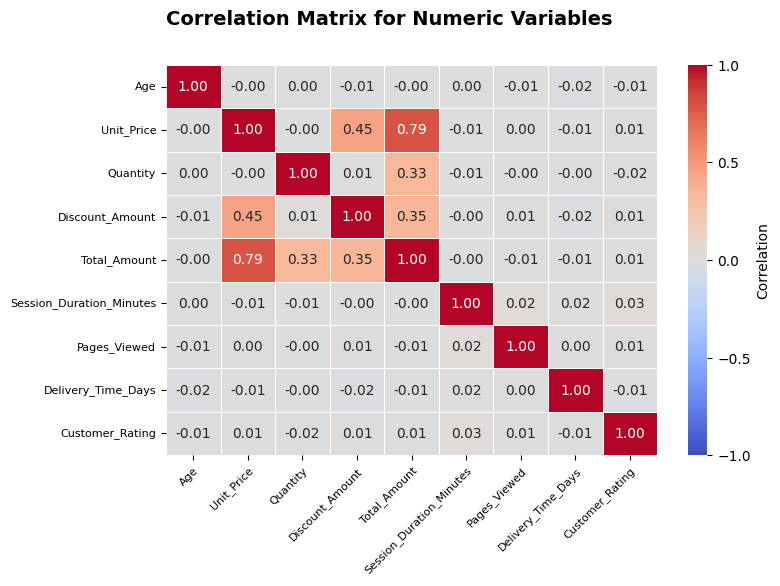

In [41]:
# Heatmap of correlations
plt.figure(figsize=(8, 6))

ax = sns.heatmap(corr_purchase ,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

The correlation heatmap shows that most numeric relationships in Dataset 4 are weak or close to zero.

The strongest relationship is between `Unit_Price` and `Total_Amount`, with a positive correlation of about 0.79. This makes sense because higher unit prices usually lead to higher total order amounts.

`Discount_Amount` also has a moderate positive relationship with `Unit_Price` and `Total_Amount`. This may mean that larger discounts are more common for higher-priced or higher-value orders.

`Quantity` has a moderate positive correlation with `Total_Amount`, around 0.33. This is expected because buying more units can increase the total order amount.

Other variables, such as `Age`, `Session_Duration_Minutes`, `Pages_Viewed`, `Delivery_Time_Days`, and `Customer_Rating`, have very weak correlations with most numeric variables.

There is no strong correlation between `Customer_Rating` and delivery time, session duration, pages viewed, or sales amount. This means customer satisfaction is not strongly explained by these numeric variables using simple linear correlation.

Overall, the main numeric relationships are connected to order value: `Unit_Price`, `Quantity`, `Discount_Amount`, and `Total_Amount`. These variables are useful for scatterplots. There is no clear evidence of strong redundancy, except that `Unit_Price` and `Total_Amount` are strongly connected because total amount is partly based on price.

#### **4.4 Scatterplots for Selected Numeric Relationships**

In this step, we draw scatterplots only for the numeric pairs that showed meaningful or business-relevant relationships in the correlation heatmap. The goal is to check whether the relationships look clear, weak, linear, clustered, or affected by high-value orders.

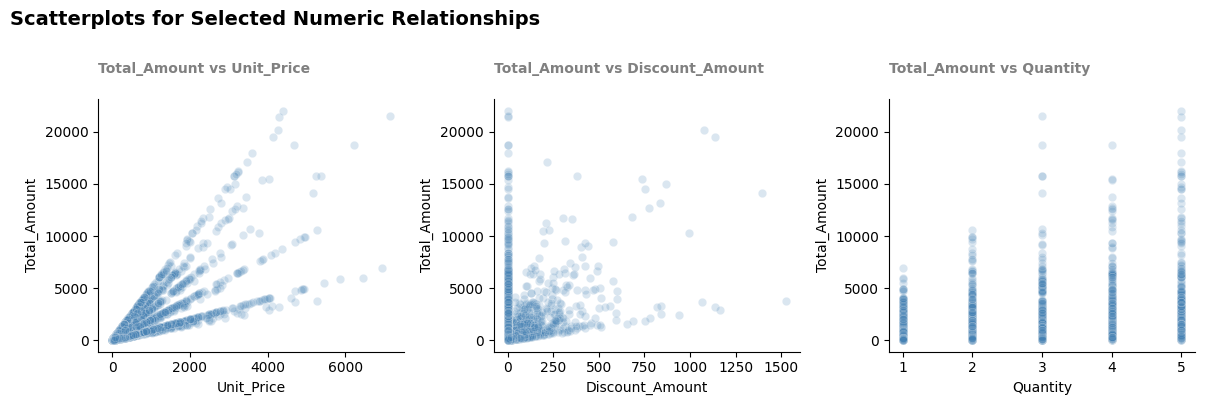

In [42]:
scatter_pairs_purchase = [("Unit_Price", "Total_Amount"),("Discount_Amount", "Total_Amount"),("Quantity", "Total_Amount")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (x_col, y_col) in enumerate(scatter_pairs_purchase):
    sns.scatterplot(data=df_purchase_experience,x=x_col, y=y_col,alpha=0.2, ax = ax[i], color="steelblue")
    ax[i].set_title(f"{y_col} vs {x_col}", loc="left", fontsize=10, fontweight="bold", pad=10, y=1.05, color="gray")
    ax[i].set_xlabel(x_col)
    ax[i].set_ylabel(y_col)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.suptitle("Scatterplots for Selected Numeric Relationships", fontsize=14, fontweight="bold", y=1, x=0, ha="left")
plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.show()

The scatterplots focus on the strongest and most business-relevant numeric relationships from the correlation heatmap.

`Total_Amount` and `Unit_Price` show the clearest positive relationship. As unit price increases, total order amount generally increases. The plot also shows several diagonal bands, which likely happen because `Total_Amount` depends on unit price and quantity.

`Total_Amount` and `Discount_Amount` show a weaker positive relationship. Many orders have zero or low discount, but larger discounts appear more often among higher-value orders.

`Total_Amount` and `Quantity` show a positive pattern, but the plot has vertical bands because `Quantity` is a discrete variable from 1 to 5. Higher quantities can lead to higher total amounts, but there is still a wide range of order values within each quantity level.

Overall, the scatterplots confirm that order value is mainly related to unit price, quantity, and discount amount. The relationships are associations and should not be interpreted as causation.

#### **4.5 Pairplot for Selected Numeric Variables**

In this step, we create a focused pairplot for the main order-value variables. We do not include all numeric variables because too many variables would make the plot crowded and less useful.

The selected variables are connected to purchase amount: unit price, quantity, discount amount, and total amount.

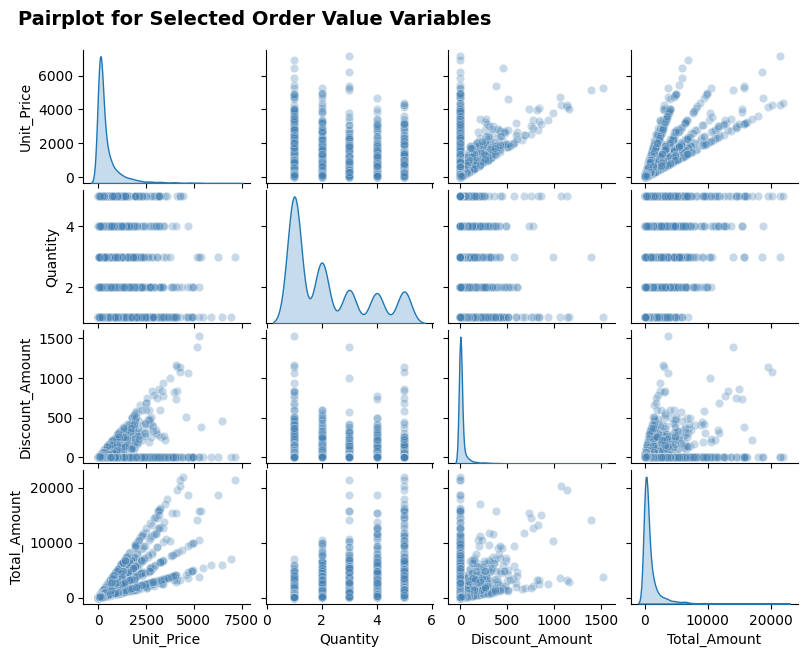

In [43]:
pairplot_cols = ["Unit_Price","Quantity","Discount_Amount","Total_Amount"]

g = sns.pairplot(data=df_purchase_experience[pairplot_cols], diag_kind="kde", plot_kws={"alpha": 0.3, "color": "steelblue"})
g.fig.set_size_inches(8, 6)
g.fig.suptitle("Pairplot for Selected Order Value Variables",fontsize=14, fontweight="bold", y=1.05, x=0.6, ha="right")
plt.show()

The pairplot confirms the main relationships seen in the correlation heatmap and scatterplots.

`Unit_Price` and `Total_Amount` show the clearest positive relationship. The diagonal band patterns suggest that total amount is strongly connected to unit price and quantity.

`Quantity` appears as horizontal and vertical bands because it is a discrete variable from 1 to 5. This makes the relationship with total amount easier to see, but it is not a smooth continuous relationship.

`Discount_Amount` and `Total_Amount` show a weaker positive pattern. Many orders have no or low discount, while some higher-value orders have larger discounts.

The diagonal histograms also show that `Unit_Price`, `Discount_Amount`, and `Total_Amount` are strongly right-skewed. Overall, the pairplot supports the idea that the most meaningful numeric relationships in this dataset are connected to order value.

#### **4.6 Time-Based Analysis**

In this step, we use the `Date` column to check monthly trends. We look at monthly total sales and monthly average customer rating to see whether purchase value or customer satisfaction changes over time.

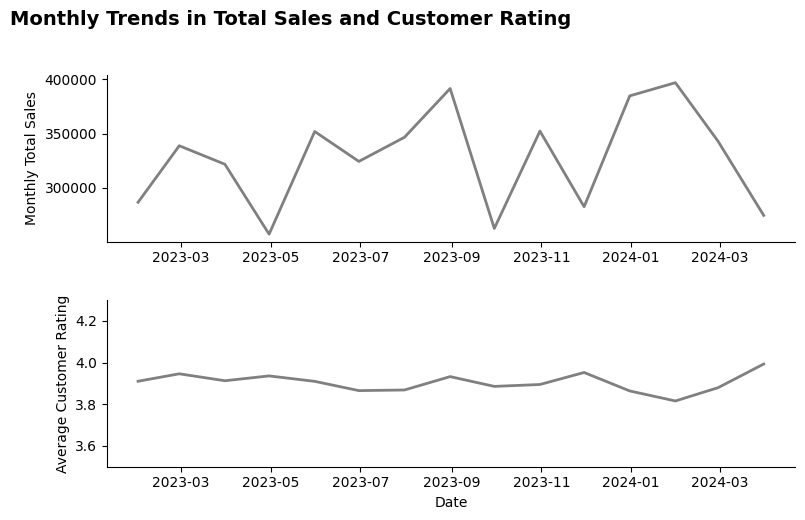

In [44]:
monthly_purchase = (df_purchase_experience.set_index("Date").resample("ME").agg({"Total_Amount": "sum","Customer_Rating": "mean"}).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

sns.lineplot(data=monthly_purchase,x="Date",y="Total_Amount",ax=ax[0],linewidth=2,markersize=5,color="gray")
ax[0].set_xlabel("")
ax[0].set_ylabel("Monthly Total Sales")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].tick_params(axis="x", labelbottom=True)

sns.lineplot(data=monthly_purchase, x="Date",y="Customer_Rating",ax=ax[1],linewidth=2,markersize=5,color="gray")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Average Customer Rating")
ax[1].set_ylim(3.5, 4.3)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].tick_params(axis="x", labelbottom=True)

fig.suptitle("Monthly Trends in Total Sales and Customer Rating",fontsize=14,fontweight="bold",y=1.03,x=0,ha="left")
plt.tight_layout()
fig.subplots_adjust(hspace=0.35)
plt.show()

The time-based plots show monthly total sales and average customer rating over time.

Monthly total sales changes across months. Some months have higher sales, and some months have lower sales. However, there is no clear steady upward or downward trend across the full period.

Average customer rating is more stable than sales. It mostly stays around 3.8 to 4.0.

Overall, sales varies from month to month, but customer rating stays fairly stable. The plots do not show a strong long-term trend or clear seasonality.

#### **4.7 Possible Confounding Variables**

In this step, we check whether categorical variables help explain differences in customer rating or purchase value. For Dataset 4, we focus on product category and returning customer status because they are useful for understanding customer satisfaction and customer value.

##### **4.7.1 Average Customer Rating by Product Category**

In this step, we compare average customer rating across product categories. This helps us see whether some product categories have higher or lower customer satisfaction.

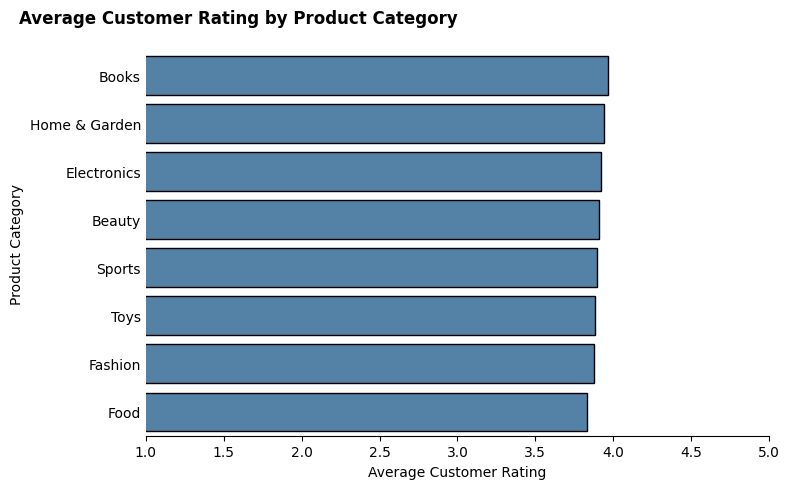

In [45]:
rating_by_category = (df_purchase_experience.groupby("Product_Category")["Customer_Rating"].mean().sort_values(ascending=False).reset_index())

plt.figure(figsize=(8, 5))
g = sns.barplot(data=rating_by_category,x="Customer_Rating",y="Product_Category",color="steelblue",edgecolor="black")

g.set_title("Average Customer Rating by Product Category", loc="left", fontsize=12, fontweight="bold", pad=15, x=0.5, ha="right", y=1.02)
g.set_xlabel("Average Customer Rating")
g.set_ylabel("Product Category")
g.set_xlim(1, 5)
g.tick_params(axis="y", length=0)
g.spines["top"].set_visible(False)
g.spines["right"].set_visible(False)
g.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

Average customer rating is very close across product categories. Books, Home & Garden, and Electronics have slightly higher average ratings, while Food has the lowest average rating among the categories.

However, the differences are small. Most categories are close to an average rating of about 4. This means product category does not strongly separate customer satisfaction in this dataset.

Overall, customer ratings are generally positive across all product categories, but there is no large satisfaction gap between categories.

##### **4.7.2 Average Total Amount by Returning Customer Status**

In this step, we compare average total order amount between new and returning customers. This helps us see whether returning customers spend more than new customers.

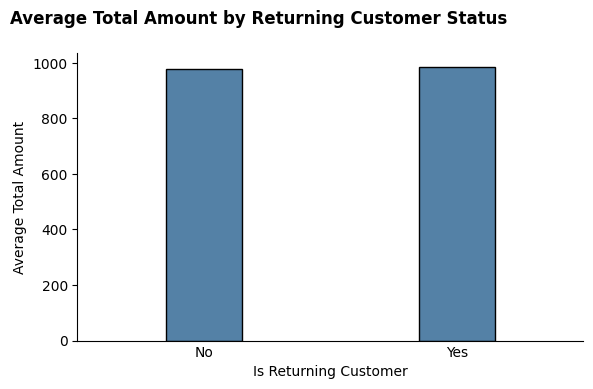

In [46]:
amount_by_returning = (df_purchase_experience.groupby("Is_Returning_Customer")["Total_Amount"].mean().reset_index())
amount_by_returning["Returning_Status"] = amount_by_returning["Is_Returning_Customer"].map({False: "No",True: "Yes"})

plt.figure(figsize=(6, 4))
g = sns.barplot(data=amount_by_returning, x="Returning_Status",y="Total_Amount",color="steelblue",edgecolor="black", width=0.3)

g.tick_params(axis="x", length=0)
g.set_title("Average Total Amount by Returning Customer Status", loc="left", fontsize=12, fontweight="bold", pad=15, y=1.03, x=0.85, ha="right")
g.set_xlabel("Is Returning Customer")
g.set_ylabel("Average Total Amount")
g.spines["top"].set_visible(False)
g.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The average total amount is very similar for new and returning customers.

Returning customers have a slightly higher average total amount, but the difference is small. This means returning customer status does not strongly separate purchase value in this dataset.

Overall, this plot suggests that returning customers do not spend much more than new customers on average.

#### **4.8 Final Conclusion for Dataset 4**

The Week 5 bivariate analysis shows that Dataset 4 is useful for studying purchase behavior, order value, customer satisfaction, and customer value.

The correlation heatmap showed that most numeric relationships are weak. The strongest relationship was between `Unit_Price` and `Total_Amount`. This makes sense because higher unit prices usually lead to higher total order amounts. `Quantity` and `Discount_Amount` also had some relationship with `Total_Amount`, but the relationships were weaker.

The scatterplots supported the correlation results. `Total_Amount` increased with `Unit_Price`, and the diagonal patterns likely come from different quantity levels. `Quantity` also affected total amount, but because it is a discrete variable, the scatterplot showed vertical bands.

The pairplot confirmed that the main numeric relationships are connected to order value. `Unit_Price`, `Quantity`, `Discount_Amount`, and `Total_Amount` were the most useful variables for pairwise analysis. Other numeric variables did not show strong relationships.

The time-based plots showed that monthly total sales changes across months. Some months have higher sales, and some months have lower sales. However, there is no clear steady upward or downward trend. Average customer rating stayed fairly stable, mostly around 3.8 to 4.0.

For customer satisfaction, average rating was very close across product categories. Some categories had slightly higher ratings, but the differences were small. This means product category does not strongly separate customer satisfaction.

For customer value, average total amount was also very similar between new and returning customers. Returning customers had a slightly higher average total amount, but the difference was small.

Overall, Dataset 4 has some useful relationships, especially around order value. The most important variables for future analysis are `Unit_Price`, `Quantity`, `Discount_Amount`, `Total_Amount`, `Product_Category`, `Customer_Rating`, and `Is_Returning_Customer`. The results show associations, not causation.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

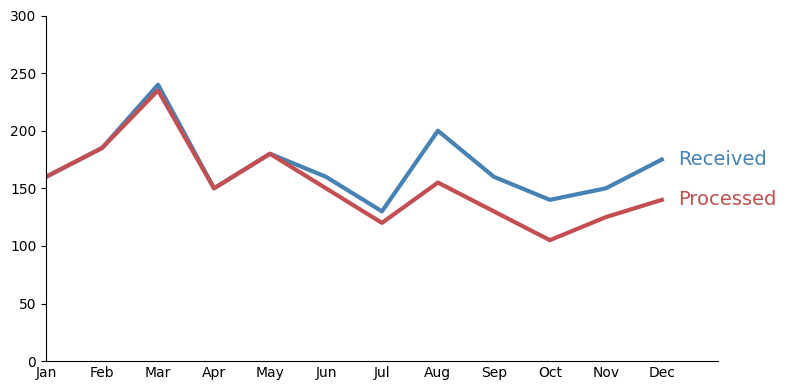

In [47]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun","Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

received = [160, 185, 240, 150, 180, 160, 130, 200, 160, 140, 150, 175]
processed = [160, 185, 235, 150, 180, 150, 120, 155, 130, 105, 125, 140]

plt.figure(figsize=(8, 4))

# Line plots
plt.plot(months, received, color="steelblue", linewidth=3)
plt.plot(months, processed, color="#C44E52", linewidth=3)

# Direct labels at the end of the lines
plt.text(11.3, received[-1], "Received", color="steelblue", fontsize=14, va="center")
plt.text(11.3, processed[-1], "Processed", color="#C44E52", fontsize=14, va="center")

# Axis limits
plt.ylim(0, 300)
plt.xlim(0, 12)

# Labels and title style
plt.tick_params(axis="x", length=0)
plt.xticks(rotation=0)
plt.yticks([0, 50, 100, 150, 200, 250, 300])

# Clean style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove legend because direct labels are used
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()